Import necessary packages and data

In [2]:
import numpy as np
import pylab as pl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import psutil
from pathlib import Path
import os

import sys
sys.path.insert(0, r'C:\Users\mqsim\neuroanalysis\code')
sys.path.insert(0, r'C:\Users\mqsim\neuroanalysis\neural-data-master\02-calcium_imaging\code')

# CaImAn funtions and objects
import caiman as cm
from caiman.motion_correction import MotionCorrect, high_pass_filter_space
from caiman.source_extraction.cnmf import params as params
from caiman.source_extraction import cnmf
from caiman.source_extraction.cnmf.cnmf import load_CNMF

import os
sys.path.append(os.path.abspath("code"))
from utils import download_data
import auxiliary_functions as aux


import seaborn as sns
sns.set_theme(context='notebook',style='white',font_scale=1.5)

In [3]:
# download data for the lesson (this can take a few minutes)
download_data('https://surfdrive.surf.nl/files/index.php/s/yQT6yv34jDu6csE')

Load video

In [3]:
# set path to video of the full field of view
input_tif_file_path_FOV = 'data/calcium_video.tif'   
input_tif_file_path = 'data/caiman_video_trial_0.tif' 

FOV = cm.load(input_tif_file_path_FOV) # load video with complete field of view (FOV)

In [4]:
print(FOV.shape)


(300, 540, 720)


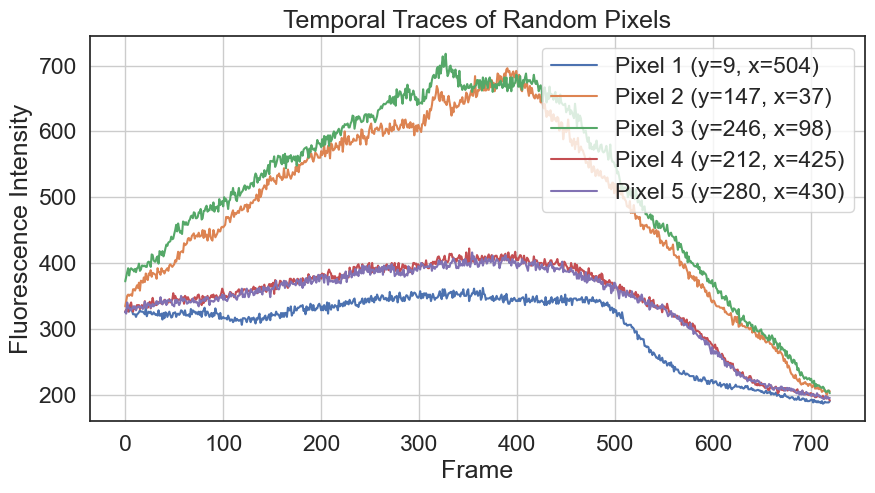

In [5]:
import numpy as np
import matplotlib.pyplot as plt

#rake random number of pixels and get coordinates
height, width, num_frames = FOV.shape
N = 5  # Number of random pixels
y_coords = np.random.randint(0, height, size=N)  # Random y-coordinates
x_coords = np.random.randint(0, width, size=N)   # Random x-coordinates

# put pixels in traces
traces = []
for y, x in zip(y_coords, x_coords):
    pixel_trace = FOV[y, x, :]  # Intensity over all frames
    traces.append(pixel_trace)

#plot pixels
plt.figure(figsize=(10, 5))
for i, trace in enumerate(traces):
    plt.plot(trace, label=f'Pixel {i+1} (y={y_coords[i]}, x={x_coords[i]})')
plt.xlabel('Frame')
plt.ylabel('Fluorescence Intensity')
plt.title('Temporal Traces of Random Pixels')
plt.legend()
plt.grid(True)
plt.show()

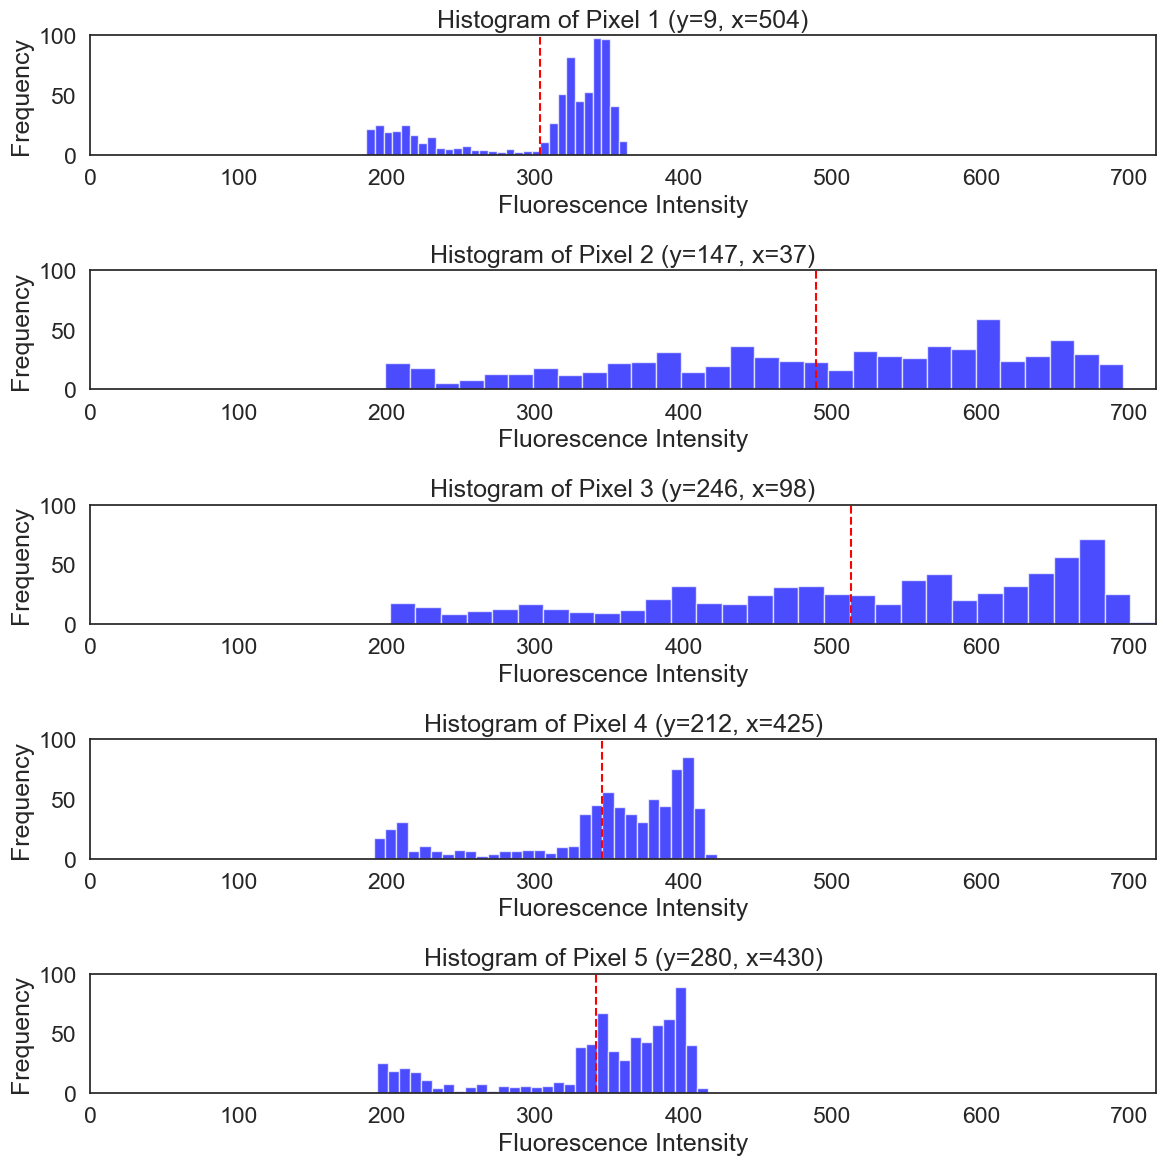

In [14]:

x_global_max = max([pixel_trace.max() for pixel_trace in traces])

# Plot histograms for each pixel
plt.figure(figsize=(12, 12))
for i, trace in enumerate(traces):
    plt.subplot(N, 1, i+1)
    plt.hist(trace, bins=30, alpha=0.7, color='blue')
    plt.title(f'Histogram of Pixel {i+1} (y={y_coords[i]}, x={x_coords[i]})')
    plt.xlabel('Fluorescence Intensity')
    plt.ylabel('Frequency')
    plt.axvline(np.mean(trace), color='red', linestyle='--', label='Mean')
    plt.xlim(0, x_global_max) # makes it easier to compare -> first took 800 as an arbitrary limit because my pixels showed fluorescence above 700, but it may cut off data if pixels are again randomly determined, so i added a global max calculation
    plt.ylim(0, 100) # dont use a global max for y, because i would need an extra calculation i didn't find worthy to do extra
plt.tight_layout()
plt.show()

## **Answers to the questions of exercise 1**

**B. Temporal statistics of pixel activation**

*For the selected pixels, plot the histogram of pixel value. What are the difference in different regions?, and how can that help to distinguish a pixel that belongs to aneuron from a background pixel?*
Apparent from the plots, pixels 1, 4 and 5 have a relatively narrow fluorescence intensity band (200-400 approx) compared to pixels 2 and 3 (fluorescence intensity band: 200-700). The frequency of these intensities occuring is particularly high for pixels 1, 4 and 5 between fluorescence intensities of 300-400, with some frequencies of 50 or higher. Contrastingly, pixels 2 and 3 rarely have a fluorescence intensity value occuring more often than 50 times. Judging from the x and y coordinates (but mostly x-coordinates), there might be an active neuron present at x-coordinate 425-500 approximately as the fluorescence profiles of pixels 1, 4 and 5 are narrow and relatively intense. Diving deeper, it might even be that there are two active neurons depicted by pixel 1 and pixels 4-5, as the fluorescnece profile of pixels 4 and 5 seem similar, and look different from pixel 1. So pixel 1 might be an active neuron and pixels 4 and 5 might be an active neuron. Pixels 2 and 3 would then be noise or neuropil, as their fluorescence profile is broad and with relatively low frequency. Deducing the histograms like this may help to distinguish a pixel belonging to a neuron from a background pixel

*If we can already see the calcium traces from individual pixels, why do we need to run source extraction to segment the neurons? Why, as a starter, would not be a good idea to work directly with the temporal traces of the pixels?*
-> without source extraction, the pixels are unfiltered, which can cause a couple of problems: 1) a neuron's signal encompasses multiple pixels, meaning that a single pixel captures but a part of the neuron's signal, including noise which may cause a low signal-to-noise ratio. If a neuron encompasses 20 pixels, each individual pixel carries 1/20th of the neurons signal plus noise. if we would use source extraction first, thereby average the signal over the pixels, we can boost the signal to noise ratio by ~sqrt(20). 2) it could be possible that neural signals overlap, causing a particular pixel to have the sum of both neural signals, misrepresenting the individual neuron signals. 3) all pixels contain some background noise. without source extraction, the pixels will be contaminated with background noise, even pixels belonging to active neurons.